In [1]:
# Imports et configuration

import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns
import uuid

pd.set_option("display.max_columns", 50)


In [2]:
# Chargement des données

# Adapter le chemin si besoin
df = pd.read_csv("../datasets/transactions_50000.csv", parse_dates=["timestamp"])

df.head()

,order_id,user_id,event_id,timestamp,nb_tickets,montant,velocity_seconds,is_fraud
0,aaed9bfe-7236-4689-9fc6-741a0dbece2b,a91b1faa-818e-4203-8239-31e783e48d70,5627f9ab-fc29-43e2-a85e-94f1d445a66c,2025-01-01 00:00:37,3,309,33.810968,0
1,5612b999-a331-44c4-a790-ed90895e610e,63aa7929-6bb2-454a-b2a0-49c8a39a4a6b,36ed8e8a-a7cb-47dd-96a5-17b5fb98f2c7,2025-01-01 00:19:12,3,165,131.372129,0
2,fa48eb0b-5093-476a-9f23-267c036fff66,c3aa994e-1bdd-49f6-98b2-5cebd8302a51,3fa7683f-bce7-4f97-a9bc-358e518dc319,2025-01-01 01:01:56,1,128,5.852311,0
3,b0d812d3-13d2-4283-b44c-e8ac862b0fbb,75016216-5c60-42d3-8f02-b91e39ed0839,a6a50633-3e55-4873-bc45-86aafc8fa1fe,2025-01-01 01:09:33,1,53,247.619547,0
4,4100fea3-ed4f-4153-9823-aa0c65611ce9,56f47b1b-acfa-4db9-a72b-70723a35200b,a6a50633-3e55-4873-bc45-86aafc8fa1fe,2025-01-01 01:23:24,2,106,75.959480,0


In [3]:
# Feature engineering (niveau utilisateur)

# Tri par user + temps
df = df.sort_values(["user_id", "timestamp"])

# Temps entre deux commandes du même user
df["delta_seconds"] = df.groupby("user_id")["timestamp"].diff().dt.total_seconds()

# Remplacer les NaN (première commande) par une valeur élevée
df["delta_seconds"] = df["delta_seconds"].fillna(999999)

# Agrégation par utilisateur
user_features = df.groupby("user_id").agg(
    nb_commandes=("order_id", "count"),
    montant_total=("montant", "sum"),
    montant_moyen=("montant", "mean"),
    nb_tickets_total=("nb_tickets", "sum"),
    nb_tickets_moyen=("nb_tickets", "mean"),
    delta_moyen=("delta_seconds", "mean"),
    delta_min=("delta_seconds", "min"),
    delta_25=("delta_seconds", lambda x: np.percentile(x, 25)),
    delta_75=("delta_seconds", lambda x: np.percentile(x, 75)),
).reset_index()

user_features.head()


,user_id,nb_commandes,montant_total,montant_moyen,nb_tickets_total,nb_tickets_moyen,delta_moyen,delta_min,delta_25,delta_75
0,00056817-958d-42a7-b587-ebde5ddaa4cc,6,604,100.666667,9,1.500000,4.655968e+06,999999.0,1767524.25,6117717.00
1,00140548-6eba-4dc0-be45-35bd60361be5,7,540,77.142857,9,1.285714,4.135537e+06,999999.0,2117809.00,5732686.50
2,0015e1e4-273b-4e86-80fc-8509491336d7,9,1558,173.111111,16,1.777778,3.315335e+06,999999.0,1328109.00,4826324.00
3,001c042a-9fed-4563-a205-47c0b6cb0c9c,6,1230,205.000000,12,2.000000,5.626651e+06,882238.0,1606197.25,6908140.25
4,001f1c61-b6aa-40b7-809a-a1c69d0ea784,4,370,92.500000,5,1.250000,1.493431e+06,304115.0,826028.00,1753199.25


In [4]:
# Ajout d’indicateurs de vélocité

# Vélocité = commandes rapides
# On définit "rapide" comme < 10 secondes entre deux commandes
df["is_rapid"] = (df["delta_seconds"] < 10).astype(int)

velocity_stats = df.groupby("user_id").agg(
    nb_rapid=("is_rapid", "sum"),
    ratio_rapid=("is_rapid", "mean")
).reset_index()

user_features = user_features.merge(velocity_stats, on="user_id", how="left")

user_features.fillna(0, inplace=True)

user_features.head()


,user_id,nb_commandes,montant_total,montant_moyen,nb_tickets_total,nb_tickets_moyen,delta_moyen,delta_min,delta_25,delta_75,nb_rapid,ratio_rapid
0,00056817-958d-42a7-b587-ebde5ddaa4cc,6,604,100.666667,9,1.500000,4.655968e+06,999999.0,1767524.25,6117717.00,0,0.0
1,00140548-6eba-4dc0-be45-35bd60361be5,7,540,77.142857,9,1.285714,4.135537e+06,999999.0,2117809.00,5732686.50,0,0.0
2,0015e1e4-273b-4e86-80fc-8509491336d7,9,1558,173.111111,16,1.777778,3.315335e+06,999999.0,1328109.00,4826324.00,0,0.0
3,001c042a-9fed-4563-a205-47c0b6cb0c9c,6,1230,205.000000,12,2.000000,5.626651e+06,882238.0,1606197.25,6908140.25,0,0.0
4,001f1c61-b6aa-40b7-809a-a1c69d0ea784,4,370,92.500000,5,1.250000,1.493431e+06,304115.0,826028.00,1753199.25,0,0.0


In [5]:
# Préparation des features pour IsolationForest

feature_cols = [
    "nb_commandes",
    "montant_total",
    "montant_moyen",
    "nb_tickets_total",
    "nb_tickets_moyen",
    "delta_moyen",
    "delta_min",
    "delta_25",
    "delta_75",
    "nb_rapid",
    "ratio_rapid"
]

X = user_features[feature_cols].copy()

# Optionnel : log-transform sur certaines variables très skewed
for col in ["montant_total", "nb_commandes", "nb_tickets_total", "delta_moyen", "delta_min"]:
    X[col] = np.log1p(X[col])


In [6]:
# Entraînement IsolationForest

from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,  # ~5% d'anomalies attendues
    random_state=42
)

iso.fit(X)

# Scores (plus c'est petit, plus c'est anormal)
scores = iso.decision_function(X)
preds = iso.predict(X)  # -1 = anomalie, 1 = normal

user_features["score_anomalie"] = -scores  # on inverse pour avoir "plus grand = plus suspect"
user_features["is_anomalie"] = (preds == -1).astype(int)

user_features.sort_values("score_anomalie", ascending=False).head()


,user_id,nb_commandes,montant_total,montant_moyen,nb_tickets_total,nb_tickets_moyen,delta_moyen,delta_min,delta_25,delta_75,nb_rapid,ratio_rapid,score_anomalie,is_anomalie
3839,63cf827a-0b8c-4585-a39b-a4e5bd9487b1,2,783,391.5,9,4.5,16419170.5,999999.0,8709584.75,24128756.25,0,0.0,0.130383,1
8941,e6384cee-18f8-4332-9ba3-2dadd7da12f7,2,895,447.5,9,4.5,13481839.5,999999.0,7240919.25,19722759.75,0,0.0,0.118898,1
9173,ebb4c150-f30a-47c9-868a-9257fefe11b8,2,58,29.0,2,1.0,13736064.0,999999.0,7368031.50,20104096.50,0,0.0,0.112955,1
8559,dc688fba-d7fe-406a-b152-75bc9a7bea63,2,99,49.5,2,1.0,15012793.0,999999.0,8006396.00,22019190.00,0,0.0,0.111714,1
6045,9c352db2-b370-49fb-b96c-52d28edf646d,2,144,72.0,2,1.0,15728855.0,999999.0,8364427.00,23093283.00,0,0.0,0.102659,1


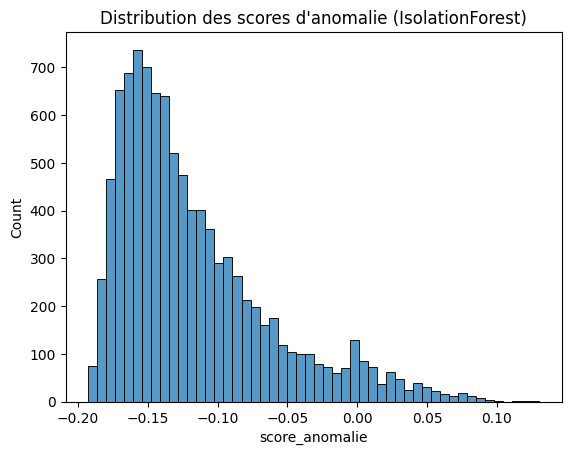

is_anomalie
0    0.949915
1    0.050085
Name: proportion, dtype: float64

In [7]:
# Visualisation rapide (optionnel mais utile pour le rapport)

sns.histplot(user_features["score_anomalie"], bins=50)
plt.title("Distribution des scores d'anomalie (IsolationForest)")
plt.show()

user_features["is_anomalie"].value_counts(normalize=True)


In [8]:
# Attribution d’un type de fraude (VELOCITY / VOLUME)

# Seuils simples (à ajuster selon ton dataset)
velocity_threshold = user_features["ratio_rapid"].quantile(0.90)
volume_threshold = user_features["montant_total"].quantile(0.90)

def classify_fraud(row):
    if row["is_anomalie"] == 0:
        return None
    if row["ratio_rapid"] >= velocity_threshold:
        return "VELOCITY"
    if row["montant_total"] >= volume_threshold:
        return "VOLUME"
    return "VELOCITY"  # par défaut

user_features["type_fraude"] = user_features.apply(classify_fraud, axis=1)

user_features[user_features["is_anomalie"] == 1].head()


,user_id,nb_commandes,montant_total,montant_moyen,nb_tickets_total,nb_tickets_moyen,delta_moyen,delta_min,delta_25,delta_75,nb_rapid,ratio_rapid,score_anomalie,is_anomalie,type_fraude
9,0037207c-af3c-49be-8ecb-80fc7cb2a9ec,13,2314,178.0,23,1.769231,2.146812e+06,21261.0,999999.00,2001495.00,0,0.0,0.015323,1,VELOCITY
28,00a5810f-9987-423a-a6fe-8f5c546798f3,3,933,311.0,9,3.000000,1.013632e+07,999999.0,7806324.50,14704474.50,0,0.0,0.043003,1,VELOCITY
37,00e5db6e-0150-4e15-9458-64dffe11cebf,2,160,80.0,4,2.000000,1.422760e+07,999999.0,7613799.75,20841401.25,0,0.0,0.069064,1,VELOCITY
40,00ebd27e-f410-43e6-a2c1-385dda5c6b80,1,35,35.0,1,1.000000,9.999990e+05,999999.0,999999.00,999999.00,0,0.0,0.046229,1,VELOCITY
45,010cafd8-ff4e-48c6-b1d3-0e81719c9771,1,105,105.0,3,3.000000,9.999990e+05,999999.0,999999.00,999999.00,0,0.0,0.014933,1,VELOCITY


In [9]:
# Projection au niveau des commandes (order_id)

# On garde seulement les users suspects
suspect_users = user_features[user_features["is_anomalie"] == 1][["user_id", "score_anomalie", "type_fraude"]]

df_fraud = df.merge(suspect_users, on="user_id", how="inner")

# On crée un id pour fraud_monitoring
df_fraud_monitoring = df_fraud[["order_id", "score_anomalie", "type_fraude"]].drop_duplicates()

df_fraud_monitoring["id"] = [str(uuid.uuid4()) for _ in range(len(df_fraud_monitoring))]

# Réordonner les colonnes
df_fraud_monitoring = df_fraud_monitoring[["id", "order_id", "score_anomalie", "type_fraude"]]

df_fraud_monitoring.head()


,id,order_id,score_anomalie,type_fraude
0,6d08a100-aa10-415c-8a57-b284d706f1a5,08ea18c8-1e7d-4947-9349-c36d327d124b,0.015323,VELOCITY
1,7e1811c8-9bf9-45ad-874d-4a7c09d2c07d,6ce3cb76-47a3-4aef-8d95-97930b3053ff,0.015323,VELOCITY
2,7a363d8a-dda7-4759-b4cb-c2a6f94c516a,a8265838-af1f-4f1c-9531-cdd45596f069,0.015323,VELOCITY
3,1ccc5493-c20e-46fb-911a-09bb84f00559,66b02ace-f2d7-4a2a-87ac-69f4767e40ae,0.015323,VELOCITY
4,0d805855-c397-4194-9644-f97ff636cf37,cd62a385-e42f-47fd-919b-f48581d9f671,0.015323,VELOCITY


In [10]:
# Export vers CSV (pour intégration backend / PostgreSQL)

output_path = "../datasets/fraud_monitoring_from_isolation_forest.csv"
df_fraud_monitoring.to_csv(output_path, index=False)

print("Fichier généré :", output_path)
print("Nombre de lignes :", len(df_fraud_monitoring))


Fichier généré : ../datasets/fraud_monitoring_from_isolation_forest.csv
Nombre de lignes : 1160
